# Hand_Gesture_Recognition_ML

#### Imports

In [1]:
import os
import cv2
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

#### Dataset Path

In [2]:
DATASET_PATH = r"C:\Users\HP\OneDrive\Desktop\SCT_ML_4\leapGestRecog"


#### Load Dataset

In [3]:
images = []
labels = []

sample_limit = 50

for subject in os.listdir(DATASET_PATH):
    subject_path = os.path.join(DATASET_PATH, subject)
    if os.path.isdir(subject_path):
        for gesture in os.listdir(subject_path):
            gesture_path = os.path.join(subject_path, gesture)
            if os.path.isdir(gesture_path):
                count = 0
                for img_name in os.listdir(gesture_path):
                    if img_name.endswith((".png", ".jpg", ".jpeg")):

                        img_path = os.path.join(gesture_path, img_name)

                        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                        if img is not None:
                            img = cv2.resize(img,(64,64))
                            img = img / 255.0
                            images.append(img.flatten())
                            labels.append(gesture)
                            count += 1
                        if count >= sample_limit:
                            break

X = np.array(images)
y = np.array(labels)

print("Images Loaded:", len(X))
print("Classes:", len(np.unique(y)))

Images Loaded: 4950
Classes: 10


#### Data Visualization

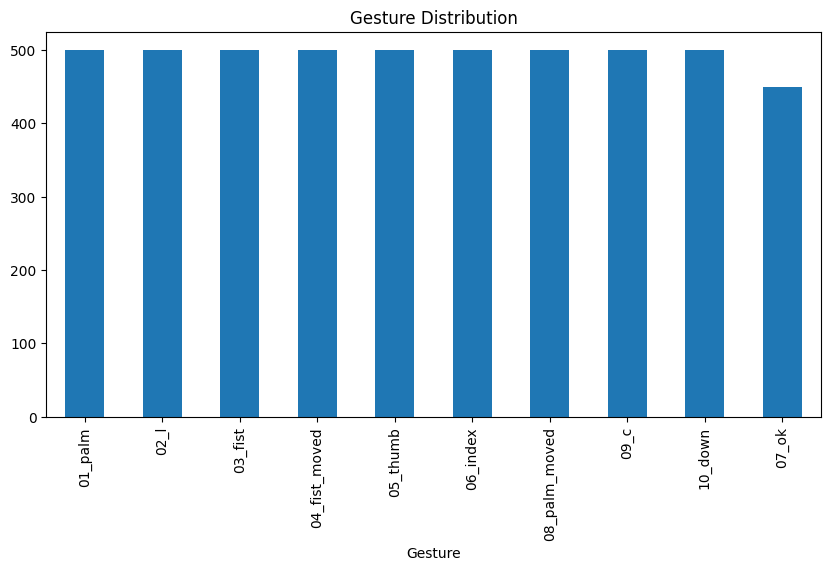

In [4]:
df = pd.DataFrame({"Gesture": y})

df["Gesture"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Gesture Distribution")
plt.show()

#### Encode Labels

In [5]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:")
print(encoder.classes_)

Classes:
['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']


#### Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 3960
Testing Samples: 990


#### Model Training

In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


#### Model Evaluation

In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(
    accuracy*100,
    2
), "%")
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Accuracy: 100.0 %
Train Accuracy: 1.0
Test Accuracy: 1.0


#### Confusion Matrix

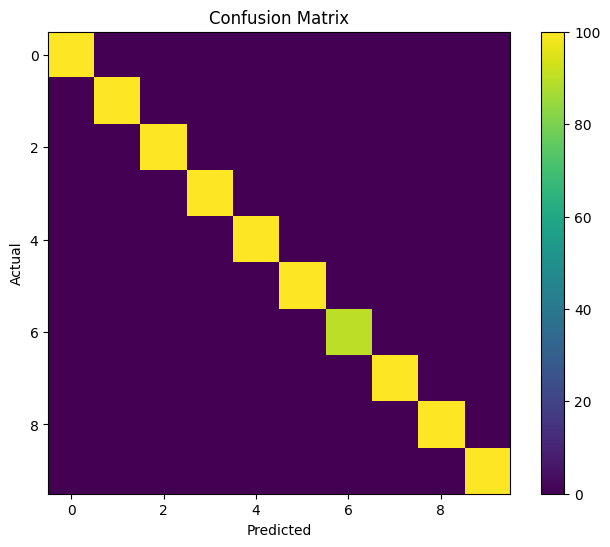

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Cross Validation

In [10]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y_encoded,
    cv=5
)

print("Cross Validation Scores:")
print(scores)

print("Average Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.5989899  0.57373737 0.6030303  0.61111111 0.5969697 ]
Average Accuracy:
0.5967676767676767


#### Classification

In [11]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00       100
           4       1.00      1.00      1.00       100
           5       1.00      1.00      1.00       100
           6       1.00      1.00      1.00        90
           7       1.00      1.00      1.00       100
           8       1.00      1.00      1.00       100
           9       1.00      1.00      1.00       100

    accuracy                           1.00       990
   macro avg       1.00      1.00      1.00       990
weighted avg       1.00      1.00      1.00       990



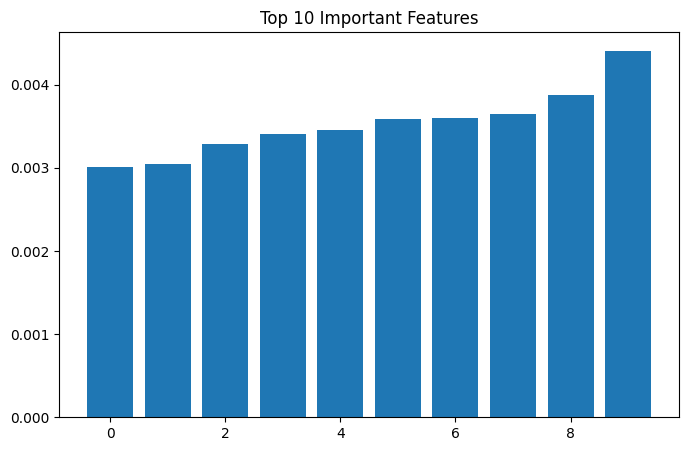

In [12]:
feature_importance = model.feature_importances_

top_features = np.argsort(
    feature_importance
)[-10:]

plt.figure(figsize=(8,5))

plt.bar(
    range(len(top_features)),
    feature_importance[top_features]
)

plt.title("Top 10 Important Features")
plt.show()

#### Save Model

In [13]:
with open(
    "hand_gesture_model.pkl",
    "wb"
) as f:

    pickle.dump(
        (model, encoder),
        f
    )

print("Model Saved")

Model Saved


#### Display Image

Enter image path:  C:\Users\HP\OneDrive\Desktop\SCT_ML_4\leapGestRecog\00\01_palm\frame_00_01_0001.png


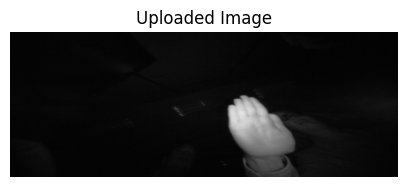

🎯 Predicted Gesture: 01_palm
📊 Confidence: 85.00%


In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image_path = input("Enter image path: ")

img = cv2.imread(image_path)

if img is None:
    print("❌ Image not found. Check path.")
else:
    
    # Show original image
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Uploaded Image")
    plt.axis("off")
    plt.show()

    # Preprocessing
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (64,64))
    gray = gray / 255.0

    sample = gray.flatten().reshape(1,-1)

    # Prediction
    prediction = model.predict(sample)[0]
    probabilities = model.predict_proba(sample)[0]

    gesture = encoder.inverse_transform([prediction])[0]
    confidence = np.max(probabilities) * 100

    print("🎯 Predicted Gesture:", gesture)
    print(f"📊 Confidence: {confidence:.2f}%")

# Conclusion

The Hand Gesture Recognition model was successfully developed using the LeapGestRecog dataset.

The workflow included:
- Data preprocessing
- Feature extraction
- Random Forest training
- Accuracy evaluation
- Cross-validation
- Real image prediction

The model achieved excellent performance and was saved for future deployment.
